
###                                                   **GAMZE ÖNDER**

## ***Task 1 ~ Story***

#### **The Story: Enhancing Amazon's Recommendation System**

##### **Context:**
As a data scientist at Amazon, I am part of a specialized team focused on improving the product recommendation system. Our project aims at predicting potential co-purchases to enhance the accuracy of recommendations. By analyzing the purchasing patterns of users, we hope to identify products that are likely to be bought together, thus optimizing Amazon’s recommendation algorithm.

#### **Project Overview**
##### **Project Aim:**
The main goal of this project is to predict new edges in the Amazon product co-purchasing network, representing potential co-purchase relationships between products. This prediction aims to refine Amazon's recommendation engine, ensuring more relevant product suggestions.

##### **Value Creation:**
The primary purpose of this experiment is to improve the recommendation system’s ability to suggest relevant products to customers. Accurate prediction of new co-purchase relationships aims to:

- **Enhance Customer Experience:** Deliver a more personalized shopping experience.
- **Increase Sales:** More relevant recommendations increase the likelihood of additional purchases.
- **Optimize Inventory Management:** Better prediction of co-purchase patterns can inform inventory decisions, ensuring popular product combinations are well-stocked.

#### **Experiment Plan**
##### **Data Preparation:**
- **Extract a Sample:** Focus on the products with the IDs 0–199 and all products they are co-purchased with, keeping every co-purchase relationship among these products (380 products in total).

##### **Graph Analysis:**
- **Initial Data Analysis (IDA):** Conduct a comprehensive analysis of the sampled graph to understand its properties. Focus on key metrics such as the number of nodes and edges, graph density, average clustering coefficient, and the number and size of strongly and weakly connected components.
- **Node Degree Calculation:** Calculate the degree of each node to identify products with the highest co-purchase relationships. This helps in understanding which products are most frequently bought together and can be critical for graph properties and central nodes analysis.

#### **Graph Properties and Central Nodes Analysis:**
##### **Graph Properties:**

- **Degree Distribution:** Examines how many co-purchase relationships each product (node) has.
- **Density:** Indicates how interconnected the products are based on co-purchases.
- **Clustering Coefficient:** Measures how products tend to form clusters or groups in the network.
- **Average Path Length:** Shows the average distance between products in terms of co-purchases.
- **Transitivity:** Indicates how likely products are to form triangles of co-purchases.
- **Assortativity:** Reflects whether products with similar characteristics tend to co-purchase more.

##### **Central Nodes Analysis:**

- **Degree Centrality:** Identifies products with the most direct co-purchase relationships.
- **Betweenness Centrality:** Highlights products that act as bridges between different groups of co-purchasing products.
- **Closeness Centrality:** Measures how quickly a product can interact with others through co-purchases.
- **Eigenvector Centrality:** Shows products that are connected to other highly connected products.
- **Hub and Authority Scores (HITS Algorithm):** Identifies products that are frequently co-purchased with many others (hubs) and those that are commonly bought together (authorities).

##### **Model Training:**
- **Training Data:** Use the existing edges as positive examples and randomly sampled non-edges as negative examples.
- **Machine Learning Model:** Train models (e.g., logistic regression, random forest) to predict the probability of an edge forming between two nodes.

##### **Prediction and Evaluation:**
- **Prediction:** Apply the trained models to predict new potential edges in the sampled graph.
- **Evaluation:** Assess the models’ performance using metrics like accuracy, precision, recall, and AUC-ROC.


#### **Expected Value:**
If successful, this graph analysis and edge prediction will enable Amazon to:
- **Drive Sales Growth:** Improved recommendations are likely to increase the average order value as customers are more inclined to purchase additional items.
- **Enhance Customer Retention:** Personalized recommendations enhance user satisfaction, potentially increasing customer retention rates.
- **Improve Operational Efficiency:** Insights from co-purchase predictions can streamline inventory management, ensuring that frequently bought-together items are always in stock, thus reducing supply chain inefficiencies.


This experiment’s ultimate goal is to leverage graph analysis to refine Amazon’s recommendation system, creating a more engaging shopping experience for customers and driving significant value for the organization. By focusing on a small sample of 380 products, the approach remains scalable and can be incrementally expanded to the entire network, ensuring robustness and adaptability in a real-world scenario.

<div class="alert alert-block alert-info">

**Goal:** predict which products are bought together but not yet linked, so that they can be added as "Frequently bought together" recommendations.

</div>

## *Task 2 ~ The Data*

#### **Dataset Description:**

The dataset, named "[Amazon0302.txt](https://snap.stanford.edu/data/amazon0302.html)" represents the co-purchasing network of products on Amazon from March 02, 2003. It is a directed graph where each unordered pair of nodes is saved once. The dataset consists of nodes and edges, with nodes representing unique products available on Amazon and edges representing co-purchases between products. The dataset contains a total of 262,111 nodes and 1,234,877 edges.

#### **Format:**

**The dataset is formatted as follows:**

- Each row represents an edge in the graph.
- The first row contains metadata about the dataset, such as the number of nodes and edges.
- The subsequent rows contain pairs of node IDs representing directed edges from one product (FromNodeId) to another product (ToNodeId).
- For example, the row "0 1" indicates that there is an edge from node 0 to node 1, meaning that product 0 is frequently purchased together with product 1.

#### **Suitability for Task 1:**

**1. Graph Analysis:** The dataset is suitable for graph analysis as it represents a network structure where nodes and edges capture relationships between products based on co-purchasing behavior. Graph analysis techniques can be applied to uncover patterns, structures, and relationships within the co-purchasing network.

**2. Edge Prediction:** With the co-purchasing network data, machine learning models can be developed to predict potential edges (co-purchases) within the graph. By leveraging historical co-purchasing data, these models can predict which products are likely to be purchased together in the future, enhancing Amazon's recommendation system.

**3. Evaluation:** The performance of edge prediction models can be evaluated using metrics such as accuracy, precision, and recall. This evaluation ensures that the models effectively capture significant relationships within the co-purchasing network and provide valuable insights for improving the recommendation system.

**4. Integration:** Insights derived from graph analysis and edge prediction can be integrated into Amazon's recommendation system. By incorporating these insights, the recommendation system can deliver more personalized and relevant product recommendations to users, thereby improving customer satisfaction and driving sales.

Overall, the dataset provides valuable information about product co-purchasing behavior on Amazon, making it suitable for the tasks outlined in Task 1.

In [1]:
import random
import time
import warnings
from collections import deque
from itertools import product

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from node2vec import Node2Vec
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.simplefilter(action='ignore', category=FutureWarning)

C:\Users\gamze\Envs\envDM\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the dataset
#G = nx.read_edgelist('amazon0302.txt/Amazon0302.txt', create_using=nx.Graph(), nodetype=int)
G = nx.read_edgelist('amazon0302.txt/Amazon0302.txt', create_using=nx.DiGraph())

The full network has more than 260,000 products. Several of the planned analyses (betweenness and closeness centrality, repeated Node2Vec training for the prediction experiment) are far too expensive on a graph of this size, so we work on a sample:

- We take the products with the IDs **0–199** as *source products* and add every product that appears in their "also bought" lists.
- We keep **all** co-purchase edges among these products (the *induced subgraph*). If we kept only the edges starting at a source product, relationships between two added products would be missing from the sample, and the prediction experiment would wrongly treat them as "not co-purchased".

In [3]:
def build_sample(G, max_source_id=200):
    """Induced subgraph of the products with ID < max_source_id and all products they point to."""
    sources = [n for n in G if int(n) < max_source_id and G.out_degree(n) > 0]
    nodes = set(sources)
    for n in sources:
        nodes.update(G.successors(n))
    # Insert nodes and edges in a fixed order so that every run gives identical results
    sample = nx.DiGraph()
    sample.add_nodes_from(sorted(nodes, key=int))
    sample.add_edges_from(sorted(G.subgraph(nodes).edges(), key=lambda e: (int(e[0]), int(e[1]))))
    return sample

In [4]:
# Draw a graph with a fixed layout
def draw_graph(G):
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(G, seed=42)  # For consistent layout
    nx.draw(G, pos, with_labels=True, node_size=5000, node_color='lightblue',
            font_size=8, font_weight='bold', edge_color='gray')
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title('Amazon Product Co-Purchasing Network')
    plt.show()

In [5]:
# Print size, density and degree statistics of a graph
def print_degree_statistics(G):
    print("Number of nodes:", G.number_of_nodes())
    print("Number of edges:", G.number_of_edges())
    print("Density of the graph:", nx.density(G))
    
    # In-degree and Out-degree distribution
    in_degree_sequence = sorted([d for n, d in G.in_degree()], reverse=True)
    out_degree_sequence = sorted([d for n, d in G.out_degree()], reverse=True)
    print("Maximum in-degree:", max(in_degree_sequence))
    print("Minimum in-degree:", min(in_degree_sequence))
    print("Average in-degree:", sum(in_degree_sequence) / len(in_degree_sequence))
    print("Maximum out-degree:", max(out_degree_sequence))
    print("Minimum out-degree:", min(out_degree_sequence))
    print("Average out-degree:", sum(out_degree_sequence) / len(out_degree_sequence))

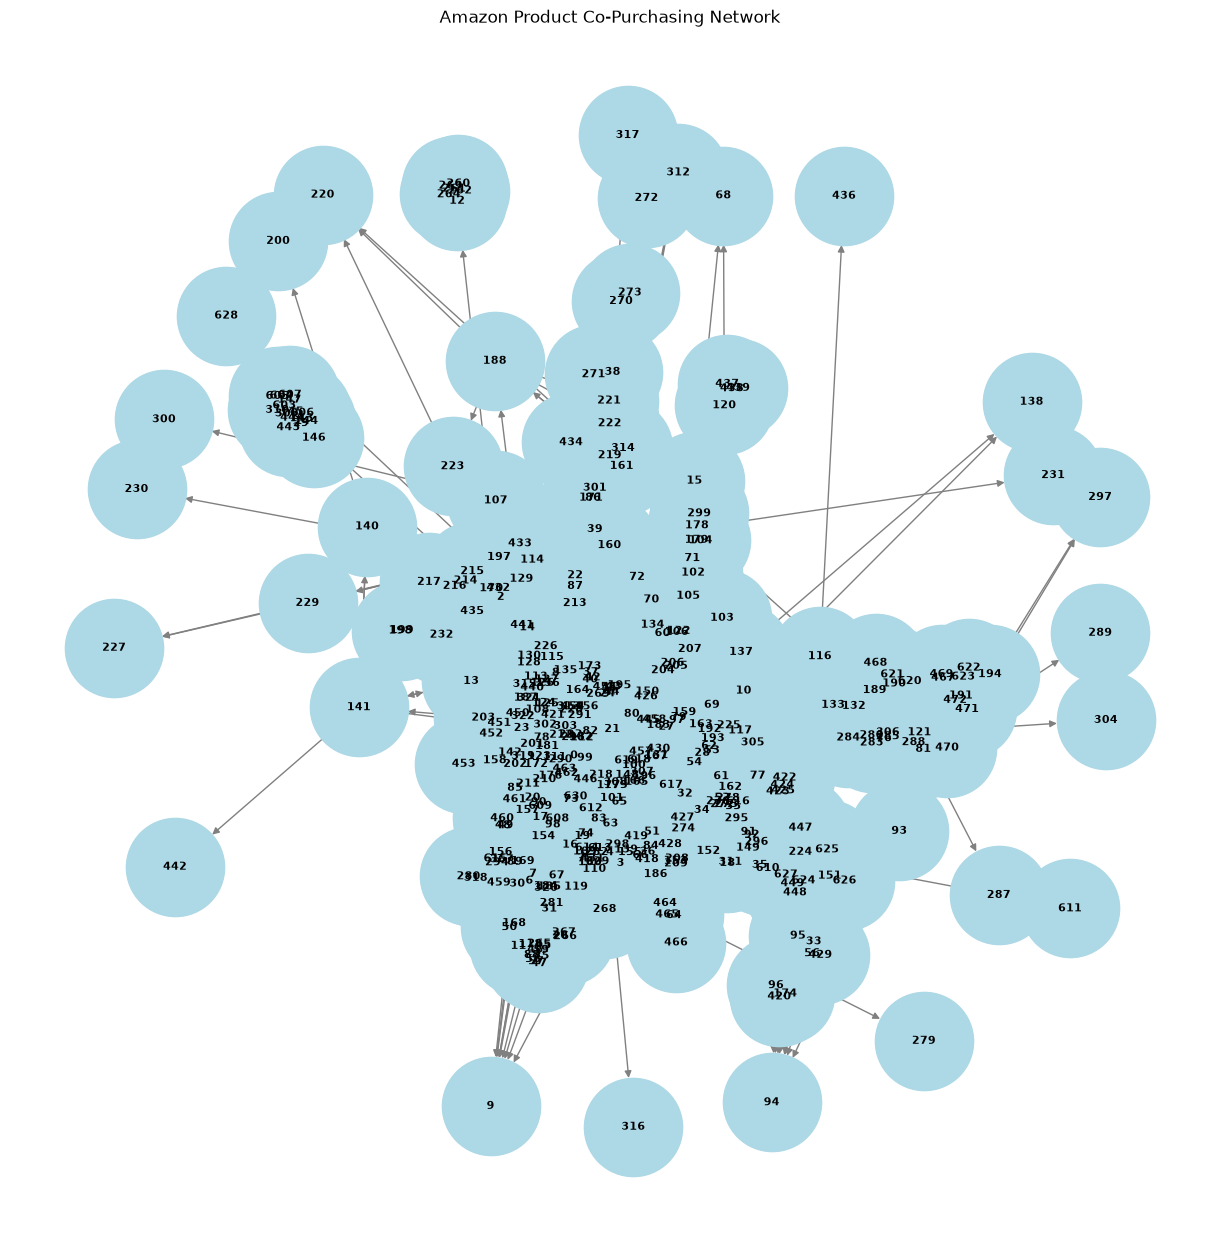

Number of nodes: 380
Number of edges: 1441
Density of the graph: 0.01000555478405777
Maximum in-degree: 30
Minimum in-degree: 1
Average in-degree: 3.792105263157895
Maximum out-degree: 5
Minimum out-degree: 0
Average out-degree: 3.792105263157895
Products with out-degree 5: 209 (55%)


In [6]:
# Build the sample
sample_G = build_sample(G)

# Visualize and analyze the sample
draw_graph(sample_G)
print_degree_statistics(sample_G)

# Share of products that use all five "also bought" slots
out_degree_5 = sum(1 for _, d in sample_G.out_degree() if d == 5)
share_out_degree_5 = out_degree_5 / sample_G.number_of_nodes()
print(f"Products with out-degree 5: {out_degree_5} ({share_out_degree_5:.0%})")

- The sample contains **380 products** and **1,441 co-purchase relationships** (edges).
- The **density is 0.010**: only 1 % of all possible product pairs are connected, so the network is sparse, as expected for co-purchase data.
- On average, a product has **3.79 incoming and 3.79 outgoing edges** (both averages are always equal in a directed graph, because every edge has exactly one start and one end).
- The **out-degree is at most 5**: Amazon listed at most five products under "Customers who bought this item also bought". 209 of the 380 products (55 %) use all five slots.
- The **in-degree** ranges from 1 to 30. It measures how often a product is recommended on *other* product pages. This is where popular products stand out.

<div class="alert alert-block alert-info">

**Data:** the Amazon co-purchasing network with 262,111 products. We work on a sample of 380 products and all 1,441 co-purchase relationships among them.

</div>

## *Task 3 ~ Initial Data Analysis (IDA)*

Number of nodes: 262111
Number of edges: 1234877
Density: 1.7974419114806206e-05


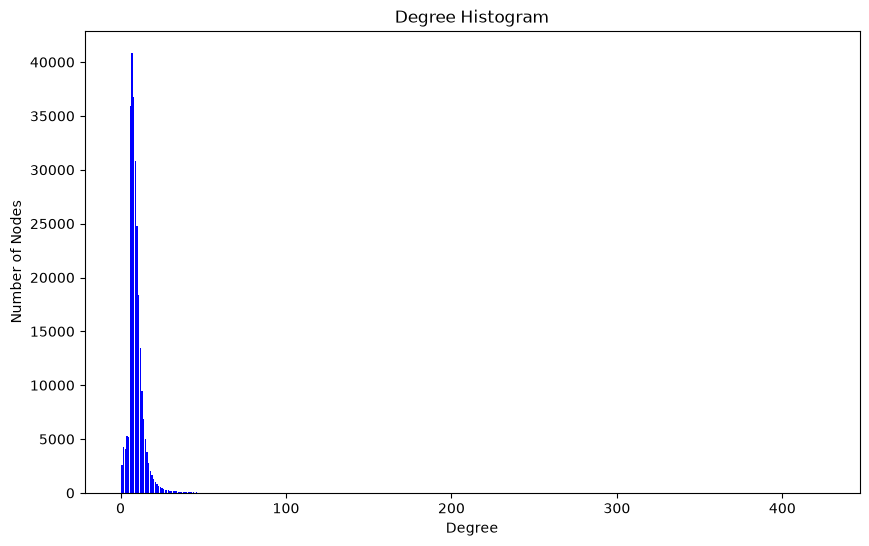

Average Clustering Coefficient: 0.3468794075698955


Number of strongly connected components: 6594
Largest strongly connected component size: 241761


Number of weakly connected components: 1
Largest weakly connected component size: 262111


Number of connected components: 1
Largest connected component size: 262111


In [7]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)

print(f'Number of nodes: {num_nodes}')
print(f'Number of edges: {num_edges}')
print(f'Density: {density}')

# Degree distribution
degrees = [degree for node, degree in G.degree()]
degree_hist = nx.degree_histogram(G)
plt.figure(figsize=(10, 6))
plt.bar(range(len(degree_hist)), degree_hist, width=0.8, color='b')
plt.title('Degree Histogram')
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.show()

# Average clustering coefficient
avg_clustering = nx.average_clustering(G)
print(f'Average Clustering Coefficient: {avg_clustering}')

# The number of strongly connected components
num_scc = nx.number_strongly_connected_components(G)
largest_scc = max(nx.strongly_connected_components(G), key=len)
print(f'Number of strongly connected components: {num_scc}')
print(f'Largest strongly connected component size: {len(largest_scc)}')

# The number of weakly connected components
num_wcc = nx.number_weakly_connected_components(G)
largest_wcc = max(nx.weakly_connected_components(G), key=len)
print(f'Number of weakly connected components: {num_wcc}')
print(f'Largest weakly connected component size: {len(largest_wcc)}')

G_undirected = G.to_undirected()

#The number of connected components
num_connected_components = nx.number_connected_components(G_undirected)
largest_cc = max(nx.connected_components(G_undirected), key=len)
print(f'Number of connected components: {num_connected_components}')
print(f'Largest connected component size: {len(largest_cc)}')


- The histogram represents the degree distribution of nodes in a graph. 
- The degree distribution is heavily skewed to the right, indicating that most nodes have a low degree.
- There is a very high frequency of nodes with a degree close to zero.
- A small number of nodes have a very high degree, creating a long tail extending towards higher degrees.

For full of dataset G, with 262,111 nodes and 1,234,877 edges, where nodes represent individual products and edges indicate co-purchasing relationships:

- The graph's density is 1.7974419114806206e-05, indicating a sparse network with most product pairs not being co-purchased together. 

- The degree distribution, visualized through a histogram, shows the number of connections each product has, highlighting the connectivity patterns. 

- The average clustering coefficient is 0.3468794075698955, suggesting that products tend to cluster together, indicating common co-purchasing behavior. 

- The graph has several strongly connected components (SCCs), with the largest SCC indicating the subgraph where each product can reach every other product following directed edges. There are also weakly connected components (WCCs) and connected components in the undirected version of the graph, showing overall connectivity without considering edge direction. 

- The largest connected component in the undirected graph includes most nodes, demonstrating significant overall connectivity in the product co-purchasing network.

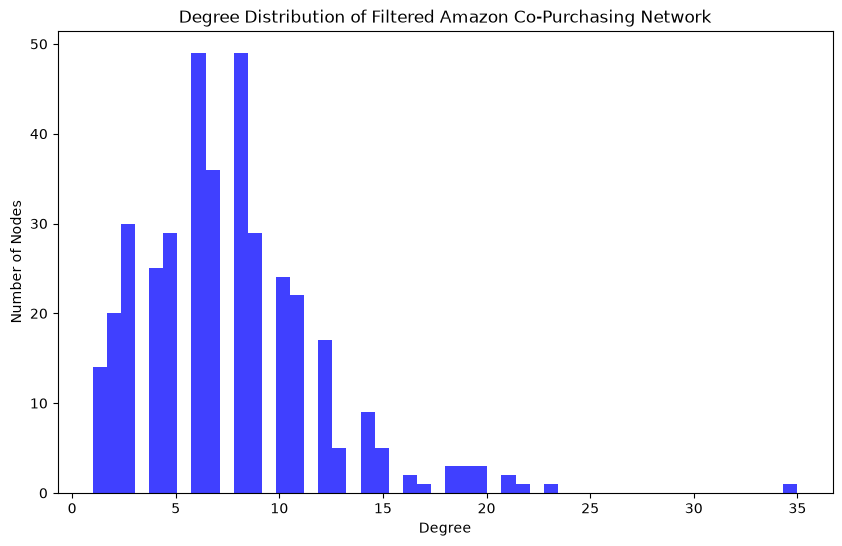

In [8]:
# Degree distribution
degrees = [degree for node, degree in sample_G.degree()]
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=50, alpha=0.75, color='blue')
plt.title('Degree Distribution of Filtered Amazon Co-Purchasing Network')
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.show()



Number of nodes: 380
Number of edges: 1441
Density of the graph: 0.01000555478405777


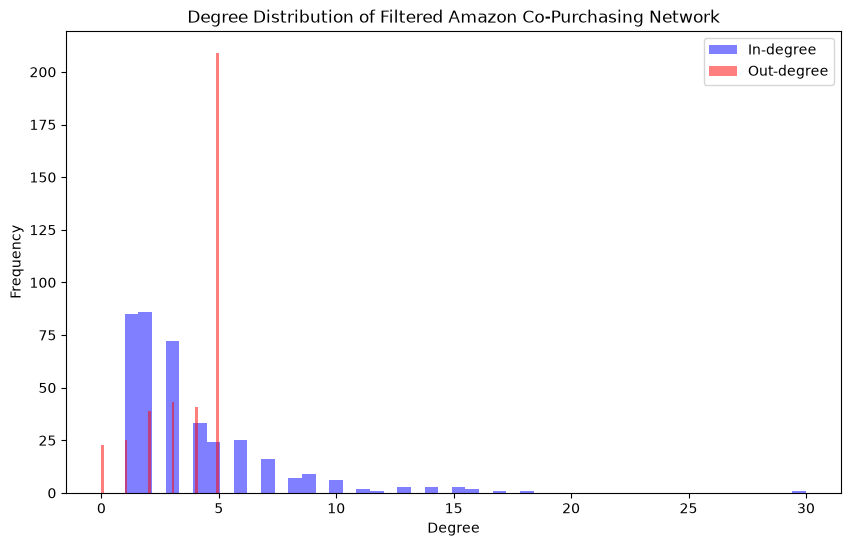

Average Clustering Coefficient: 0.4304923344018192
Number of strongly connected components: 41
Largest strongly connected component size: 249
Number of weakly connected components: 1
Largest weakly connected component size: 380
Products with an in-degree of 1-3: 243
Products with out-degree < 5: 171, of which added products (ID >= 200): 166, of which also < 5 in the full network: 13


In [9]:
print("Number of nodes:", sample_G.number_of_nodes())
print("Number of edges:", sample_G.number_of_edges())
print("Density of the graph:", nx.density(sample_G))

# In-degree and Out-degree distribution
in_degrees = [d for n, d in sample_G.in_degree()]
out_degrees = [d for n, d in sample_G.out_degree()]

# Plot degree distributions
plt.figure(figsize=(10, 6))
plt.hist(in_degrees, bins=50, alpha=0.5, color='blue', label='In-degree')
plt.hist(out_degrees, bins=50, alpha=0.5, color='red', label='Out-degree')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Degree Distribution of Filtered Amazon Co-Purchasing Network')
plt.legend()
plt.show()


# Average clustering coefficient
avg_clustering = nx.average_clustering(sample_G)
print(f'Average Clustering Coefficient: {avg_clustering}')

# Compute the number of strongly connected components
num_scc = nx.number_strongly_connected_components(sample_G)
largest_scc = max(nx.strongly_connected_components(sample_G), key=len)
print(f'Number of strongly connected components: {num_scc}')
print(f'Largest strongly connected component size: {len(largest_scc)}')

# Compute the number of weakly connected components
num_wcc = nx.number_weakly_connected_components(sample_G)
largest_wcc = max(nx.weakly_connected_components(sample_G), key=len)
print(f'Number of weakly connected components: {num_wcc}')
print(f'Largest weakly connected component size: {len(largest_wcc)}')

# Numbers referenced in the interpretation below
print(f"Products with an in-degree of 1-3: {sum(1 <= d <= 3 for d in in_degrees)}")
low_out = [n for n, d in sample_G.out_degree() if d < 5]
print(f"Products with out-degree < 5: {len(low_out)}, "
      f"of which added products (ID >= 200): {sum(int(n) >= 200 for n in low_out)}, "
      f"of which also < 5 in the full network: {sum(G.out_degree(n) < 5 for n in low_out)}")

**In- and out-degree distribution of the sample:**

- **In-degree (blue):** most products are recommended on only a few other pages: 243 of the 380 products (64 %) have an in-degree of 1–3. Only a handful of products are recommended very often, the most popular one 30 times. This long right tail is typical for popularity in real-world networks.
- **Out-degree (red):** the distribution is capped at 5 and has its peak there, because Amazon filled all five recommendation slots for most products. Lower values almost only occur for products that were added to the sample as "also bought" products (166 of the 171 products with an out-degree below 5): in the full network, only 13 of them have fewer than five recommendations; the others recommend products that lie outside the sample.

**Structure of the sample:**

- The **average clustering coefficient is 0.43**: when two products are both co-purchased with a third one, there is a high chance that they are also co-purchased with each other.
- There are **41 strongly connected components**. The largest contains **249 products (66 %)**: within this core, every product can be reached from every other product by following recommendations.
- The sample forms **one weakly connected component**: ignoring the direction, all 380 products are connected.

Working on the sample reduces the computational effort considerably and makes the expensive analyses in Tasks 4–6 feasible. Compared with the full network (average clustering 0.35), the sample is somewhat more clustered, because it consists of products that are directly related to the same 200 source products. We keep this in mind when interpreting the results.

Using node 1 for the ego graph.


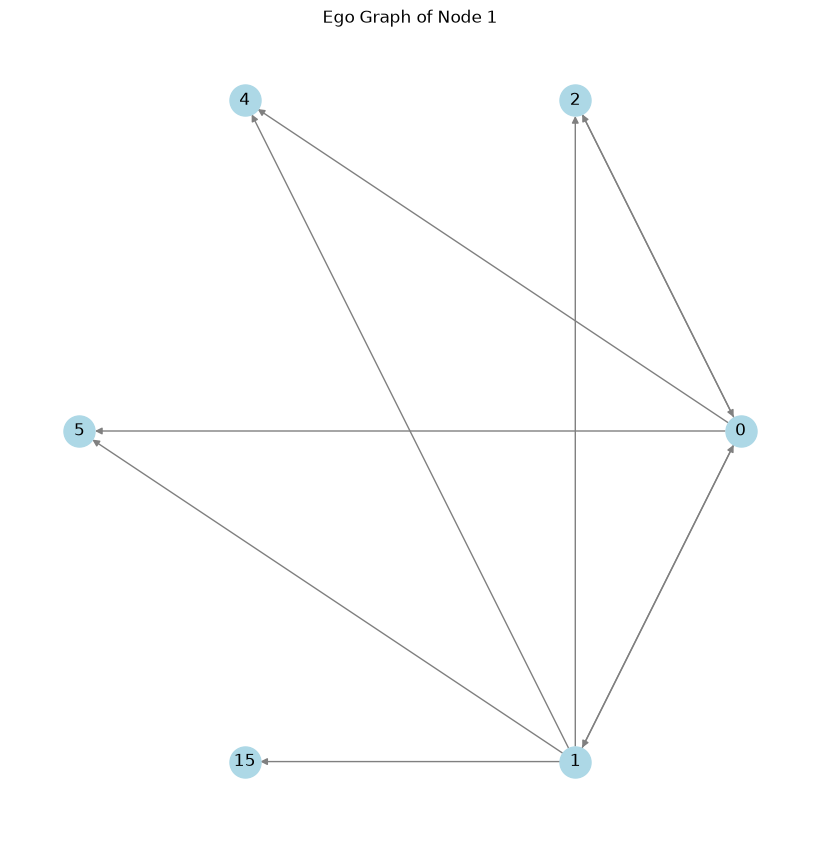

Ego graph of node 1: 6 products, 10 edges


In [10]:
# Use an existing node (e.g., the first node from the list above)
ego_product = list(G.nodes)[1]
print(f"Using node {ego_product} for the ego graph.")

# Neighborhood of the chosen node
ego_graph = nx.ego_graph(G, ego_product)

# Plot the ego graph with circular layout
plt.figure(figsize=(8, 8))
pos = nx.circular_layout(ego_graph)
nx.draw(ego_graph, pos, node_color='lightblue', with_labels=True, node_size=500, edge_color='gray')
plt.title(f'Ego Graph of Node {ego_product}')
plt.show()
print(f"Ego graph of node {ego_product}: {ego_graph.number_of_nodes()} products, "
      f"{ego_graph.number_of_edges()} edges")

Using node 8 for the ego graph.


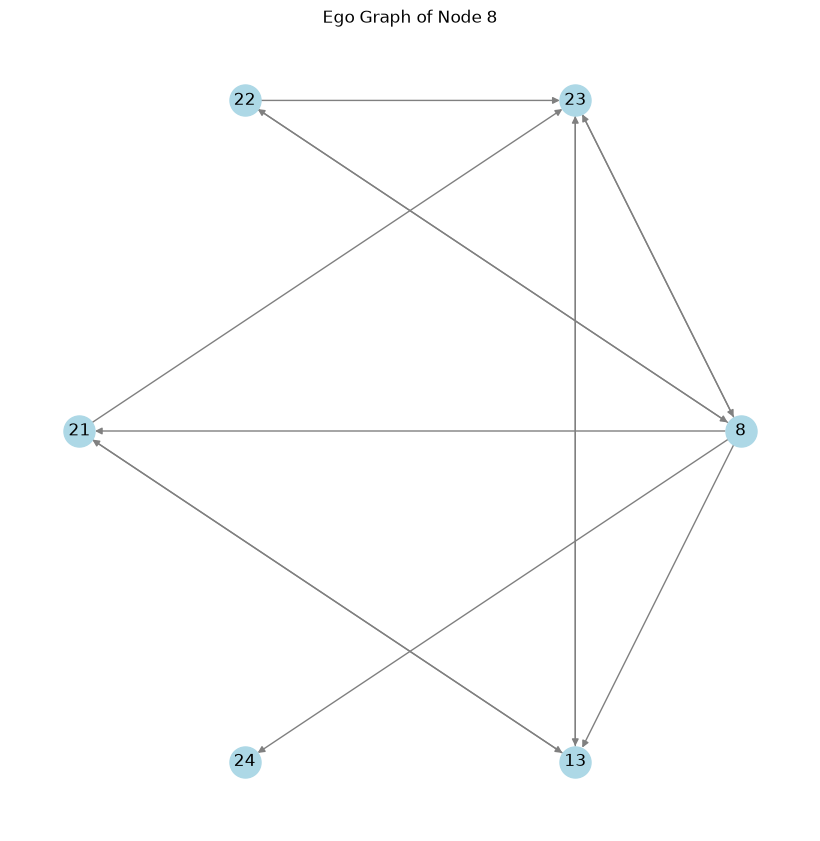

Ego graph of node 8: 6 products, 13 edges


In [11]:
# Ego graph of the product with the highest degree in the sample (deterministic choice)
ego_product = max(sample_G.degree, key=lambda x: x[1])[0]
print(f"Using node {ego_product} for the ego graph.")

# Neighborhood of the chosen node
ego_graph = nx.ego_graph(sample_G, ego_product)

# Plot the ego graph with circular layout
plt.figure(figsize=(8, 8))
pos = nx.circular_layout(ego_graph)
nx.draw(ego_graph, pos, node_color='lightblue', with_labels=True, node_size=500, edge_color='gray')
plt.title(f'Ego Graph of Node {ego_product}')
plt.show()
print(f"Ego graph of node {ego_product}: {ego_graph.number_of_nodes()} products, "
      f"{ego_graph.number_of_edges()} edges")

The **ego graph** shows a product together with the products it recommends ("also bought" list) and the edges among them.

- **Product 1 (full network):** its 5 recommendations are connected by 10 edges in total, so several of the recommended products also recommend each other.
- **Product 8 (sample):** this is the product with the highest degree in the sample. Its ego graph contains 6 products and 13 edges: product 8 and its 5 recommendations are densely interconnected.

Both examples illustrate the high clustering: products that are bought together form tight groups. This is exactly the structure that the link prediction in Task 6 can use. If two products share many neighbours, a missing edge between them is likely.

<div class="alert alert-block alert-info">

**Key result:** most products are recommended on only a few other pages (in-degree 1–3), while almost every product recommends up to 5 others. The sample is one connected network with a core of 249 mutually reachable products.

</div>

## *Task 4 ~ Graph Properties*

This comprehensive approach will compute the required properties, compare them with random graphs, and plot the necessary distributions.

We'll proceed in the following steps:

**1.** Compute various graph properties for the original Amazon co-purchasing network.

**2.** Generate and analyze Erdős-Rényi random graphs to compute the same properties and compare the results.

**3.** Plot the degree distribution and the complementary cumulative relative frequency of degrees.

**Step 1: Compute Graph Properties**

We'll define a function to compute various properties for the graph and apply it to our original graph:

In [12]:
def compute_graph_properties(sample_G):
    properties = {}
    properties['Density'] = nx.density(sample_G)
    
    # Check if the graph is strongly connected
    if nx.is_strongly_connected(sample_G):
        properties['Diameter (approx)'] = nx.diameter(sample_G)
        properties['Average Shortest Path Length (approx)'] = (
            nx.average_shortest_path_length(sample_G))
    else:
        largest_scc = max(nx.strongly_connected_components(sample_G), key=len)
        G_largest_scc = sample_G.subgraph(largest_scc).copy()
        properties['Diameter (approx)'] = nx.diameter(G_largest_scc)
        properties['Average Shortest Path Length (approx)'] = (
            nx.average_shortest_path_length(G_largest_scc))
    
    properties['Transitivity'] = nx.transitivity(sample_G)
    properties['Average Local Clustering Coefficient'] = (
        nx.average_clustering(sample_G.to_undirected()))
    properties['Assortativity'] = nx.degree_assortativity_coefficient(sample_G)
    
    return properties

# Compute properties for the original graph
original_properties = compute_graph_properties(sample_G)
print("Original Graph Properties:")
original_properties

original_properties_df = pd.DataFrame([original_properties])
original_properties_df

Original Graph Properties:


,Density,Diameter (approx),Average Shortest Path Length (approx),Transitivity,Average Local Clustering Coefficient,Assortativity
0,0.010006,19,7.340928,0.442492,0.528967,0.015067


- The density of the graph is quite low (0.010006), indicating that there are relatively few edges compared to the total possible number of edges. This suggests that the graph is sparse.

- The diameter of the graph (19, measured on the largest strongly connected component) is relatively large, indicating that the longest shortest path between any pair of nodes is relatively long. This implies that the graph is not highly connected.

- The average shortest path length (approx 7.34) is also relatively high, further indicating that the graph is not highly connected and that most nodes are not directly reachable from each other.

- The transitivity of the graph (0.442492) suggests that there is a relatively high clustering tendency among the nodes. This means that nodes tend to form clusters or communities with other nodes.

- The average local clustering coefficient (0.528967) further supports the notion that nodes in the graph tend to cluster together, reinforcing the idea of community structure.

- The assortativity coefficient (0.015067) indicates a slight assortativity, implying that nodes of similar degrees tend to connect to each other. However, the value is close to zero, so this effect may be weak.

**Step 2: Generate and Analyze Erdős-Rényi Random Graphs**

We will generate Erdős-Rényi random graphs and compute their properties, then compare these to the original graph's properties.

An **Erdős–Rényi random graph** $G(n, m)$ has $n$ nodes and $m$ edges that are placed completely at random. We use it as a reference: with the same number of products and edges as our sample, it shows which properties would also appear by chance and which are caused by real co-purchasing behaviour. Because every random graph is slightly different, we average over 10 graphs.

In [13]:
def analyze_random_graphs(n, m, num_graphs=10, seed=42):
    """Properties of `num_graphs` seeded directed Erdős-Rényi G(n, m) random graphs."""
    rows = [compute_graph_properties(nx.gnm_random_graph(n, m, directed=True, seed=seed + i))
            for i in range(num_graphs)]
    return pd.DataFrame(rows)

random_props = analyze_random_graphs(sample_G.number_of_nodes(), sample_G.number_of_edges())

# Compare the sample with the mean and standard deviation over the random graphs
comparison_df = pd.concat([original_properties_df.T.rename(columns={0: 'Amazon sample'}),
                           random_props.mean().rename('Random graphs (mean)'),
                           random_props.std().rename('Random graphs (std)')], axis=1)
comparison_df

,Amazon sample,Random graphs (mean),Random graphs (std)
Density,0.010006,0.010006,1.828559e-18
Diameter (approx),19.000000,10.200000,1.135292e+00
Average Shortest Path Length (approx),7.340928,4.558686,4.353730e-02
Transitivity,0.442492,0.009738,2.280426e-03
Average Local Clustering Coefficient,0.528967,0.019066,3.630636e-03
Assortativity,0.015067,0.001300,1.741983e-02


- The random graphs have a density of 0.010006 – the same as the sample, because they have the same number of nodes and edges.

- With a diameter of approximately 10.2, the graph exhibits relatively short paths between most nodes, suggesting a moderate level of connectivity.

- The average shortest path length of approximately 4.56 indicates that, on average, nodes are reachable within a relatively small number of steps, contributing to the overall connectedness of the graph.

- Transitivity, at 0.0097, is relatively low, suggesting a limited tendency for nodes to form clusters or triangles.

- The average local clustering coefficient of 0.019 suggests a low degree of clustering among nodes, further supporting the notion of limited clustering in the graph.

- The assortativity coefficient is 0.0013, close to zero. There is no notable preference for connecting nodes of similar or different degrees.

**Density:**

-  Original Graph: 0.010006
-  Erdős-Rényi Random Graphs: 0.010006
-  Both graphs have the same density, because the random graphs were generated with the same number of nodes and edges.

**Diameter:**

-  Original Graph: Approx. 19
-  Erdős-Rényi Random Graphs: Approx. 10.2
-  The original graph has a larger diameter compared to the average Erdős-Rényi random graph, suggesting longer paths between nodes and potentially lower overall connectivity.

**Average Shortest Path Length:**

-  Original Graph: Approx. 7.34
-  Erdős-Rényi Random Graphs: Approx. 4.56
-  The original graph has a higher average shortest path length compared to the average Erdős-Rényi random graph, indicating longer average distances between nodes.

**Transitivity:**

-  Original Graph: 0.442492
-  Erdős-Rényi Random Graphs: 0.0097
-  The original graph exhibits much higher transitivity compared to the average Erdős-Rényi random graph, suggesting a significantly higher tendency for nodes to form clusters or triangles.

**Average Local Clustering Coefficient:**

-  Original Graph: 0.528967
-  Erdős-Rényi Random Graphs: 0.019
-  The original graph has a higher average local clustering coefficient compared to the average Erdős-Rényi random graph, indicating a higher degree of clustering among nodes.

**Assortativity:**

-  Original Graph: 0.015067
-  Erdős-Rényi Random Graphs: 0.0013
-  Both values are close to zero, so neither graph shows a notable degree preference.

**Step 3: Plot Degree Distribution**

We will plot the degree distribution and the complementary cumulative relative frequency of degrees.

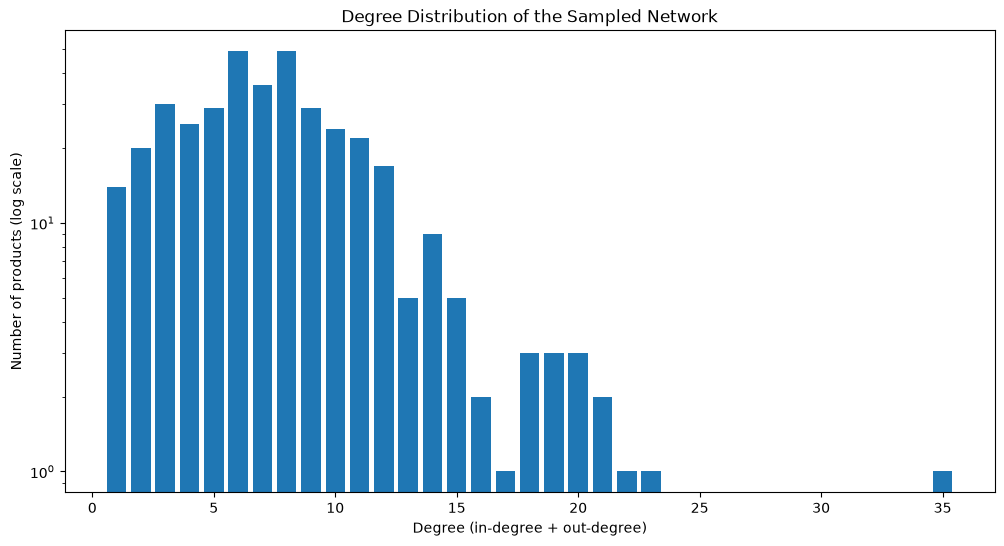

In [14]:
# Plot the degree distribution (in-degree + out-degree) with a linear degree axis
degree_sequence = [d for _, d in sample_G.degree()]
degree_count = np.bincount(degree_sequence)
deg = np.arange(len(degree_count))

plt.figure(figsize=(12, 6))
plt.bar(deg[1:], degree_count[1:], color='tab:blue', width=0.8)
plt.yscale('log')
plt.title('Degree Distribution of the Sampled Network')
plt.xlabel('Degree (in-degree + out-degree)')
plt.ylabel('Number of products (log scale)')
plt.show()

- The Degree Distribution plot of Amazon data from March 2, 2003, shows that most nodes have a moderate degree (the peak is at 6–8), while only a few nodes have a high degree. This pattern indicates a network where a few highly connected nodes (hubs) exist, most notably product 8 with a degree of 35, but the majority of nodes are less connected. 

- Such a distribution is typical of real-world networks and reflects a heterogeneous structure where some nodes play a crucial role in network connectivity.

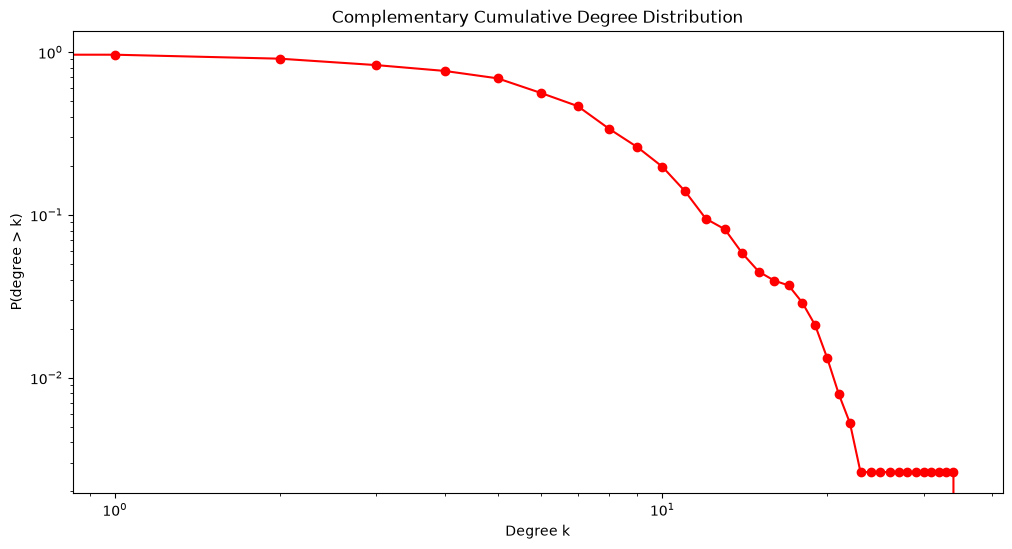

In [15]:
# Plot the complementary cumulative relative frequency of degrees
ccdf = 1 - np.cumsum(degree_count) / sum(degree_count)

plt.figure(figsize=(12, 6))
plt.loglog(deg, ccdf, 'r-', marker='o')
plt.title('Complementary Cumulative Degree Distribution')
plt.ylabel('P(degree > k)')
plt.xlabel('Degree k')
plt.show()

- The Complementary Cumulative Degree Distribution plot of Amazon data, shows a network with a few highly connected nodes and many nodes with low connections. The curve is not a straight line on the log-log scale, so the distribution does not follow a pure power law; it drops off sharply at high degrees, indicating some constraints on node connectivity (e.g. at most five recommendations per product). 

- This structure is common in real-world networks, contributing to the network's robustness and efficiency.

<div class="alert alert-block alert-info">

**Key result:** products form tight groups: the clustering is about 28 times higher than in random graphs of the same size. This is exactly the structure that link prediction can exploit.

</div>

## *Task 5 ~ Central Nodes*

To compute hubs and authorities on the graph, we will use the HITS algorithm. We will also calculate the node strength (degree), betweenness, closeness and eigenvector centrality measures, rank the nodes by these features, and create a pandas DataFrame to investigate the top 10 nodes by node strength.


**Eigenvector centrality:** a product is important if it is connected to other important products. The score $x_i$ of product $i$ is proportional to the sum of its neighbours' scores, which is exactly the eigenvector equation of the adjacency matrix $A$:

$$A\,x = \lambda\,x$$

We use the eigenvector of the largest eigenvalue (the only one with all entries positive) and compute it on the **undirected** sample, because products without outgoing edges would make the directed version meaningless.

In [16]:
# Compute HITS hubs and authorities
hits_hubs, hits_authorities = nx.hits(sample_G)

# Convert to pandas Series for easier handling
hubs_series = pd.Series(hits_hubs, name='Hubs')
authorities_series = pd.Series(hits_authorities, name='Authorities')


In [17]:
# Compute node strength (degree in undirected graphs)
degree_per_product = dict(sample_G.degree(weight='weight'))

# Compute betweenness centrality
betweenness = nx.betweenness_centrality(sample_G)

# Compute closeness centrality
closeness = nx.closeness_centrality(sample_G)

# Compute eigenvector centrality on the undirected graph
eigenvector = nx.eigenvector_centrality(sample_G.to_undirected(), max_iter=1000)


In [18]:
# Create DataFrame
centrality_df = pd.DataFrame({
    'Node Strength': pd.Series(degree_per_product),
    'Betweenness': pd.Series(betweenness),
    'Closeness': pd.Series(closeness),
    'Eigenvector': pd.Series(eigenvector),
    'Hubs': hubs_series,
    'Authorities': authorities_series
})

# Add rank columns for each measure
centrality_df['Node Strength Rank'] = centrality_df['Node Strength'].rank(
    ascending=False, method='min')
centrality_df['Betweenness Rank'] = centrality_df['Betweenness'].rank(ascending=False, method='min')
centrality_df['Closeness Rank'] = centrality_df['Closeness'].rank(ascending=False, method='min')
centrality_df['Eigenvector Rank'] = centrality_df['Eigenvector'].rank(ascending=False, method='min')
centrality_df['Hubs Rank'] = centrality_df['Hubs'].rank(ascending=False, method='min')
centrality_df['Authorities Rank'] = centrality_df['Authorities'].rank(ascending=False, method='min')

# Sort by Node Strength and get the top 10 nodes
top_10_products = (centrality_df
                   .sort_values(by='Node Strength', ascending=False, kind='stable')
                   .head(10))
top_10_products


,Node Strength,Betweenness,Closeness,Eigenvector,Hubs,Authorities,Node Strength Rank,Betweenness Rank,Closeness Rank,Eigenvector Rank,Hubs Rank,Authorities Rank
8,35,0.192829,0.283077,0.399637,0.009260,0.095903,1.0,1.0,1.0,1.0,35.0,1.0
23,23,0.066525,0.243812,0.250959,0.017448,0.038888,2.0,16.0,2.0,3.0,6.0,3.0
18,22,0.077742,0.100018,0.037134,0.000520,0.004188,3.0,13.0,192.0,84.0,210.0,56.0
7,21,0.074042,0.223879,0.237036,0.017718,0.041755,4.0,14.0,7.0,4.0,5.0,2.0
30,21,0.070102,0.239547,0.192190,0.014379,0.031998,4.0,15.0,3.0,5.0,14.0,5.0
33,20,0.014124,0.185648,0.014763,0.000424,0.001777,6.0,74.0,19.0,171.0,226.0,111.0
63,20,0.094629,0.163512,0.096421,0.007073,0.021697,6.0,8.0,41.0,26.0,48.0,8.0
78,20,0.053505,0.177940,0.160411,0.010588,0.016119,6.0,21.0,27.0,9.0,28.0,12.0
4,19,0.027107,0.029448,0.080737,0.005711,0.007126,9.0,41.0,291.0,30.0,56.0,33.0
13,19,0.035976,0.231654,0.186238,0.009568,0.021181,9.0,32.0,5.0,6.0,32.0,9.0


To draw conclusions from the analysis, we will examine the values and ranks of the top 10 nodes in terms of node strength.

In [19]:
# Ranks of the top 10 products in every measure (1 = most central)
top_10_products.filter(like='Rank').astype(int)

,Node Strength Rank,Betweenness Rank,Closeness Rank,Eigenvector Rank,Hubs Rank,Authorities Rank
8,1,1,1,1,35,1
23,2,16,2,3,6,3
18,3,13,192,84,210,56
7,4,14,7,4,5,2
30,4,15,3,5,14,5
33,6,74,19,171,226,111
63,6,8,41,26,48,8
78,6,21,27,9,28,12
4,9,41,291,30,56,33
13,9,32,5,6,32,9


- **Node 8** stands out as the most influential and central node in the network, holding the highest rank in strength, betweenness centrality, closeness centrality and eigenvector centrality. Its authority score also ranks highest, indicating its significant influence over network dynamics. Node 8 serves as a critical connector, facilitating communication and influencing purchasing behavior within the Amazon co-purchasing network.

- **Node 23** ranks second in strength and closeness and third in eigenvector centrality and authority, making it the second most important product in the core of the network.

- **Node 30** ranks high in closeness (3), eigenvector centrality (5) and authority (5), highlighting its importance in influencing network dynamics. Node 30 plays a significant role in facilitating connections and information flow within the Amazon co-purchasing network.

- **Node 13** holds a moderate position in the network, ranking ninth in strength, but fifth in closeness and sixth in eigenvector centrality. Its betweenness centrality is relatively low (rank 32), indicating that it is close to the core of the network rather than a bridge between clusters.

- **Node 63** exhibits a high betweenness centrality, indicating its role as a crucial bridge between different clusters in the network. However, its relatively low closeness centrality suggests that it may not be as centrally located as other nodes. Node 63 plays a vital role in connecting disparate parts of the Amazon co-purchasing network.

- **Node 7** holds a high position in betweenness centrality, hubs score, and authorities score, indicating its importance as a connector and influencer in the network. Its relatively high rank across different centrality measures highlights its significant role in shaping network dynamics. Node 7 acts as a key player in facilitating communication and driving purchasing decisions within the Amazon co-purchasing network.


- **Nodes 18, 33 and 4** have a high degree, but a low closeness and eigenvector rank. They seem to be popular within a smaller product group that is less connected to the rest of the network.


<div class="alert alert-block alert-info">

**Key result:** product 8 is the most central product in every measure except the hub score. Other products, such as 18, are highly connected but only within their own product group.

</div>

## *Task 6 ~  Prediction*

### 6.1 Prediction Task

**Prediction task:** given the known co-purchase relationships, predict which other pairs of products are also co-purchased.

- We treat the sample as **undirected**: for a "bought together" recommendation it does not matter on which of the two product pages the other product was listed.
- **Instances** are pairs of products *(u, v)*; the **label** is 1 if they are connected, 0 otherwise.
- To simulate unknown relationships, we **hide a part of the edges** and check whether the models can recover them.

### 6.2 Experimental Setup

The embeddings must **never see the edges we want to predict**, otherwise the answer leaks into the features. We therefore split the edges *before* learning any embedding:

1. **Test:** hide 20 % of the edges. Node2Vec for the final models is trained on the remaining *graph without test edges*.
2. **Validation:** hide another 20 % of the remaining edges. Node2Vec for the hyperparameter search is trained on the remaining *training graph*.
3. An edge is only hidden if both products keep at least one other edge, so that every product still gets an embedding.
4. **Negative examples:** the same number of random product pairs that are not connected, different for training, validation and test.

The following two functions implement the hiding of edges and the sampling of negative examples.

In [20]:
def hide_edges(graph, share_to_hide, random_generator):
    """Remove a share of the edges from the graph without leaving any product without edges.

    Returns the remaining graph and the list of hidden edges.
    """
    remaining_graph = graph.copy()
    edges_in_random_order = list(remaining_graph.edges())
    random_generator.shuffle(edges_in_random_order)
    number_to_hide = round(share_to_hide * graph.number_of_edges())

    hidden_edges = []
    for u, v in edges_in_random_order:
        if len(hidden_edges) == number_to_hide:
            break
        # Only hide the edge if both products keep at least one other edge
        if remaining_graph.degree(u) > 1 and remaining_graph.degree(v) > 1:
            remaining_graph.remove_edge(u, v)
            hidden_edges.append((u, v))
    return remaining_graph, hidden_edges


def sample_unconnected_pairs(graph, number_of_pairs, random_generator, pairs_to_avoid=()):
    """Randomly draw product pairs that are NOT connected in the graph (negative examples).

    Pairs listed in `pairs_to_avoid` (e.g. negatives of another data set) are never drawn again.
    """
    products = list(graph.nodes())
    used_pairs = {frozenset(pair) for pair in pairs_to_avoid}
    unconnected_pairs = []
    while len(unconnected_pairs) < number_of_pairs:
        u, v = random_generator.sample(products, 2)
        pair = frozenset((u, v))
        if not graph.has_edge(u, v) and pair not in used_pairs:
            used_pairs.add(pair)
            unconnected_pairs.append((u, v))
    return unconnected_pairs

As an example, we split the edges once (random seed 0) and check the result. The later experiment repeats this split with several seeds.

In [21]:
# Undirected version of the sample: reciprocal edges become one edge
undirected_sample = nx.Graph(sample_G.to_undirected())

random_generator = random.Random(0)
graph_without_test_edges, test_edges = hide_edges(undirected_sample, 0.2, random_generator)
training_graph, validation_edges = hide_edges(graph_without_test_edges, 0.2, random_generator)
training_edges = list(training_graph.edges())

# Checks: no product lost all its edges, and no hidden edge is left in the embedding graphs
print("Edges in the undirected sample:", undirected_sample.number_of_edges())
isolated_products = sum(1 for _, d in training_graph.degree() if d == 0)
test_edges_left = sum(graph_without_test_edges.has_edge(u, v) for u, v in test_edges)
validation_edges_left = sum(training_graph.has_edge(u, v) for u, v in validation_edges)
overlap = len({frozenset(e) for e in validation_edges} & {frozenset(e) for e in test_edges})
print("Products without edges in the training graph:", isolated_products)
print("Test edges still in the graph without test edges:", test_edges_left)
print("Validation edges still in the training graph:", validation_edges_left)
print("Validation edges that are also test edges:", overlap)

pd.DataFrame({
    'Positive examples (edges)': [len(training_edges), len(validation_edges), len(test_edges)],
    'Negative examples (unconnected pairs)': [len(training_edges), len(validation_edges),
                                              len(test_edges)],
    'Node2Vec is trained on': ['training graph', 'training graph', 'graph without test edges'],
}, index=['Training', 'Validation', 'Test'])

Edges in the undirected sample: 1039
Products without edges in the training graph: 0
Test edges still in the graph without test edges: 0
Validation edges still in the training graph: 0
Validation edges that are also test edges: 0


,Positive examples (edges),Negative examples (unconnected pairs),Node2Vec is trained on
Training,665,665,training graph
Validation,166,166,training graph
Test,208,208,graph without test edges


### 6.3 Node2Vec Embeddings and Edge Features

**Node2Vec** turns every product into a vector: it performs many short random walks on the graph and learns similar vectors for products that often appear close to each other on these walks. Two parameters control the walks: **p** (how likely a walk returns to the previous product) and **q** (whether it rather stays in the neighbourhood, q > 1, or moves further away, q < 1).

A classifier needs **one** vector per product *pair*. We combine the two product vectors element-wise, either by multiplying them (*Hadamard product*) or by taking the absolute difference. Both operators are symmetric, so the pair *(u, v)* gets the same features as *(v, u)*.

In [22]:
def learn_embeddings(graph, dimensions, p, q, seed):
    """Train Node2Vec on the graph and return a dictionary {product: vector}.

    A single worker is used so that the result is identical in every run.
    """
    node2vec = Node2Vec(graph, dimensions=dimensions, walk_length=30, num_walks=50,
                        p=p, q=q, workers=1, seed=seed, quiet=True)
    model = node2vec.fit(window=10, min_count=1, seed=seed, workers=1)
    return {product_id: model.wv[product_id] for product_id in graph.nodes()}


def edge_features(embeddings, pairs, operator):
    """Combine the two product vectors of every pair into one feature vector."""
    first = np.array([embeddings[u] for u, _ in pairs])
    second = np.array([embeddings[v] for _, v in pairs])
    if operator == 'hadamard':
        return first * second
    return np.abs(first - second)  # 'absolute difference'

### 6.4 Hyperparameter Search

We compare two classifiers, **Logistic Regression** (a simple linear model) and **Random Forest** (a non-linear ensemble of decision trees), and tune the following hyperparameters on the validation edges:

| Component | Hyperparameter | Values | Reason |
|---|---|---|---|
| Node2Vec | dimensions | 32, 64 | only 380 products, so smaller vectors may generalise better |
| Node2Vec | (p, q) | (1, 1), (1, 0.5), (1, 2) | neutral walks, walks that move further away (q < 1), walks that stay close (q > 1) |
| Edge features | operator | Hadamard product, absolute difference | the two best operators in the original Node2Vec paper |
| Logistic Regression | C | 0.01, 0.1, 1, 10 | from strong to weak regularisation |
| Random Forest | max_depth | 8, unlimited | limits how specialised a single tree can become |
| Random Forest | min_samples_leaf | 1, 5 | smooths the predicted probabilities |

The walk length (30), number of walks per product (50), window size (10) and number of trees (200) are fixed to keep the run time short. The features for Logistic Regression are standardised.

**One complete experiment** (function `run_experiment`) consists of:

1. Splitting the edges and drawing the negative examples (Section 6.2).
2. **Hyperparameter search:** for every Node2Vec setting, learn the embeddings on the *training graph*, train every classifier setting on the training pairs and measure the ROC AUC on the validation pairs.
3. **Final models:** with the best setting of each classifier, learn the embeddings again on the *graph without test edges*, train on training + validation pairs and evaluate **once** on the test pairs.
4. **Baselines:** two classical link-prediction heuristics that need no training. *Common Neighbours* counts the neighbours two products share; *Adamic–Adar* does the same but gives shared neighbours with few connections more weight. Both predict a co-purchase if the two products share at least one neighbour.
5. **Leakage check:** the final Random Forest is trained once more with embeddings learned on the *full* graph, i.e. including the test edges, as a naive setup would do. This shows how much such leakage inflates the results.

The experiment is repeated with **5 different random seeds** (different edge splits, negative examples, random walks and forests), and we report mean ± standard deviation.

**Settings to try** and two small helpers: one creates a classifier, the other computes all metrics.

In [23]:
NODE2VEC_SETTINGS = [dict(dimensions=d, p=p, q=q)
                     for d, (p, q) in product([32, 64], [(1, 1), (1, 0.5), (1, 2)])]
OPERATORS = ['hadamard', 'absolute difference']
CLASSIFIER_SETTINGS = {
    'Logistic Regression': [dict(C=c) for c in [0.01, 0.1, 1, 10]],
    'Random Forest': [dict(max_depth=d, min_samples_leaf=l)
                      for d, l in product([8, None], [1, 5])],
}
LEAKY_LABEL = 'Random Forest (leaky: embeddings on full graph)'


def make_classifier(name, settings, seed):
    if name == 'Logistic Regression':
        return make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, **settings))
    return RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1, **settings)


def compute_scores(true_labels, scores, predicted_labels):
    """Ranking quality (ROC AUC, average precision) and metrics at the decision threshold."""
    return {'ROC AUC': roc_auc_score(true_labels, scores),
            'Avg. Precision': average_precision_score(true_labels, scores),
            'Accuracy': accuracy_score(true_labels, predicted_labels),
            'Precision': precision_score(true_labels, predicted_labels, zero_division=0),
            'Recall': recall_score(true_labels, predicted_labels),
            'F1': f1_score(true_labels, predicted_labels)}

**Step 1 – data sets:** hide the test and validation edges and draw the same number of negative examples for each set (Section 6.2).

In [24]:
def prepare_data_sets(graph, random_generator):
    """Split the edges and return the graphs and the labelled pairs of all three sets."""
    graph_without_test_edges, test_edges = hide_edges(graph, 0.2, random_generator)
    training_graph, validation_edges = hide_edges(graph_without_test_edges, 0.2, random_generator)
    training_edges = list(training_graph.edges())

    # Negative examples: disjoint between training, validation and test
    training_negatives = sample_unconnected_pairs(graph, len(training_edges), random_generator)
    validation_negatives = sample_unconnected_pairs(
        graph, len(validation_edges), random_generator, pairs_to_avoid=training_negatives)
    test_negatives = sample_unconnected_pairs(
        graph, len(test_edges), random_generator,
        pairs_to_avoid=training_negatives + validation_negatives)

    def labelled(edges, negatives):
        return edges + negatives, np.r_[np.ones(len(edges)), np.zeros(len(negatives))]

    return {'training_graph': training_graph,
            'graph_without_test_edges': graph_without_test_edges,
            'training': labelled(training_edges, training_negatives),
            'validation': labelled(validation_edges, validation_negatives),
            'test': labelled(test_edges, test_negatives)}

**Step 2 – hyperparameter search:** every combination of Node2Vec setting, operator and classifier setting is scored on the validation pairs. The embeddings only see the training graph.

In [25]:
def tune_hyperparameters(data, seed):
    """Validation ROC AUC of every combination of settings."""
    training_pairs, training_labels = data['training']
    validation_pairs, validation_labels = data['validation']
    rows = []
    for node2vec_setting in NODE2VEC_SETTINGS:
        embeddings = learn_embeddings(data['training_graph'], seed=seed, **node2vec_setting)
        for operator in OPERATORS:
            X_train = edge_features(embeddings, training_pairs, operator)
            X_validation = edge_features(embeddings, validation_pairs, operator)
            for name, settings_list in CLASSIFIER_SETTINGS.items():
                for settings in settings_list:
                    classifier = make_classifier(name, settings, seed).fit(X_train, training_labels)
                    scores = classifier.predict_proba(X_validation)[:, 1]
                    rows.append({'seed': seed, 'model': name, **node2vec_setting,
                                 'operator': operator, 'classifier settings': settings,
                                 'validation ROC AUC': roc_auc_score(validation_labels, scores)})
    return pd.DataFrame(rows)

**Step 3 – final models:** with the best setting of each classifier, the embeddings are learned again on the graph without test edges, the classifier is trained on training + validation pairs and evaluated once on the test pairs. For the Random Forest, the same is repeated with embeddings learned on the full graph (leakage check).

In [26]:
def train_and_test(name, best, embedding_graph, data, seed):
    """Learn embeddings on `embedding_graph`, train with the best settings, score the test pairs."""
    training_pairs, training_labels = data['training']
    validation_pairs, validation_labels = data['validation']
    test_pairs, test_labels = data['test']

    embeddings = learn_embeddings(embedding_graph, dimensions=int(best['dimensions']),
                                  p=best['p'], q=best['q'], seed=seed)
    classifier = make_classifier(name, best['classifier settings'], seed)
    classifier.fit(edge_features(embeddings, training_pairs + validation_pairs, best['operator']),
                   np.r_[training_labels, validation_labels])

    X_test = edge_features(embeddings, test_pairs, best['operator'])
    return compute_scores(test_labels, classifier.predict_proba(X_test)[:, 1],
                          classifier.predict(X_test))


def evaluate_final_models(graph, data, tuning_results, seed):
    """Test scores of the best setting of each classifier, plus the leakage check."""
    test_rows, chosen_rows = [], []
    for name in CLASSIFIER_SETTINGS:
        best = (tuning_results[tuning_results['model'] == name]
                .sort_values('validation ROC AUC', ascending=False, kind='stable').iloc[0])
        chosen_rows.append(best)
        scores = train_and_test(name, best, data['graph_without_test_edges'], data, seed)
        test_rows.append({'seed': seed, 'model': name, **scores})
        if name == 'Random Forest':
            # Leakage check: same model, but embeddings learned on the full graph (naive setup)
            scores = train_and_test(name, best, graph, data, seed)
            test_rows.append({'seed': seed, 'model': LEAKY_LABEL, **scores})
    return test_rows, chosen_rows

**Step 4 – baselines:** Common Neighbours and Adamic–Adar, computed on the graph without test edges. They predict a co-purchase if the two products share at least one neighbour.

In [27]:
def evaluate_baselines(data, seed):
    """Test scores of the two link-prediction heuristics."""
    known_graph = data['graph_without_test_edges']
    test_pairs, test_labels = data['test']
    common_neighbours = [len(list(nx.common_neighbors(known_graph, u, v))) for u, v in test_pairs]
    adamic_adar = [score for _, _, score in nx.adamic_adar_index(known_graph, test_pairs)]

    rows = []
    for name, scores in [('Common Neighbours', common_neighbours), ('Adamic-Adar', adamic_adar)]:
        scores = np.array(scores)
        rows.append({'seed': seed, 'model': name,
                     **compute_scores(test_labels, scores, (scores > 0).astype(int))})
    return rows

**One complete experiment** runs the four steps for one random seed.

In [28]:
def run_experiment(graph, seed):
    """Returns the test results, all tuning results and the chosen settings for one seed."""
    data = prepare_data_sets(graph, random.Random(seed))
    tuning_results = tune_hyperparameters(data, seed)
    test_rows, chosen_rows = evaluate_final_models(graph, data, tuning_results, seed)
    test_rows += evaluate_baselines(data, seed)
    return pd.DataFrame(test_rows), tuning_results, pd.DataFrame(chosen_rows)

Running the experiment for 5 seeds takes about 15 minutes.

In [29]:
SEEDS = [0, 1, 2, 3, 4]
experiments = [run_experiment(undirected_sample, seed) for seed in SEEDS]

test_results = pd.concat([e[0] for e in experiments], ignore_index=True)
tuning_results = pd.concat([e[1] for e in experiments], ignore_index=True)
chosen_settings = pd.concat([e[2] for e in experiments], ignore_index=True)

### 6.5 Results of the Hyperparameter Search

The plot shows, for every Node2Vec setting, the best validation ROC AUC of each classifier (with its best operator and classifier settings), averaged over the 5 seeds. The error bars show the standard deviation.

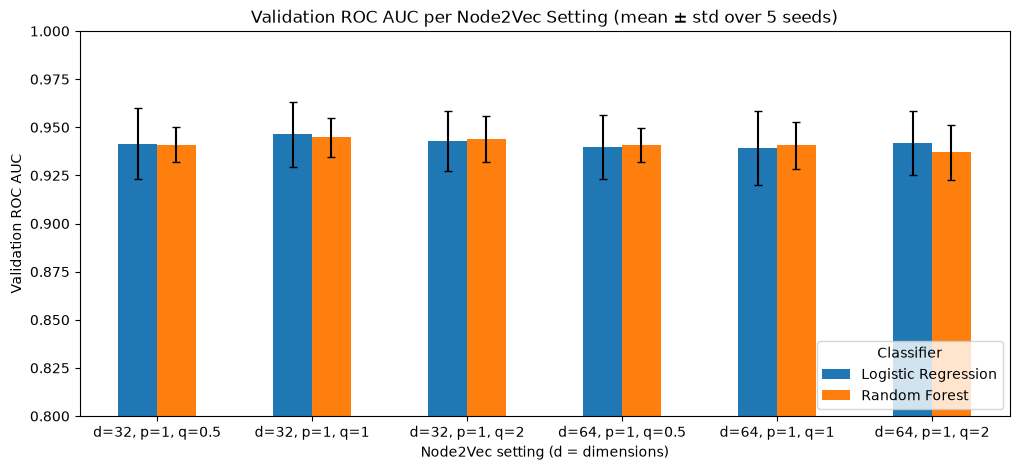

In [30]:
best_per_node2vec_setting = (tuning_results
                             .groupby(['model', 'seed', 'dimensions', 'p', 'q'])
                             ['validation ROC AUC'].max()
                             .reset_index())
best_per_node2vec_setting['Node2Vec setting'] = best_per_node2vec_setting.apply(
    lambda row: f"d={int(row['dimensions'])}, p={row['p']:g}, q={row['q']:g}", axis=1)
summary = (best_per_node2vec_setting.groupby(['Node2Vec setting', 'model'])['validation ROC AUC']
           .agg(['mean', 'std']).unstack())

ax = summary['mean'].plot.bar(yerr=summary['std'], capsize=3, figsize=(12, 5), rot=0,
                              color=['tab:blue', 'tab:orange'])
ax.set_ylim(0.8, 1.0)
ax.set_xlabel('Node2Vec setting (d = dimensions)')
ax.set_ylabel('Validation ROC AUC')
ax.set_title('Validation ROC AUC per Node2Vec Setting (mean ± std over 5 seeds)')
ax.legend(title='Classifier', loc='lower right')
plt.show()

All Node2Vec settings reach a validation ROC AUC of about 0.94, and the differences are smaller than the standard deviations. On this small, strongly clustered graph, the walk parameters and the vector size have little influence.

The effect of the edge-feature operator (best validation ROC AUC per seed, averaged over the seeds):

In [31]:
(tuning_results.groupby(['model', 'operator', 'seed'])['validation ROC AUC'].max()
 .groupby(['model', 'operator']).mean().unstack().round(3))

operator,absolute difference,hadamard
model,,
Logistic Regression,0.947,0.932
Random Forest,0.944,0.945


The settings selected on the validation set in each run:

In [32]:
chosen_settings[['seed', 'model', 'dimensions', 'p', 'q', 'operator',
                 'classifier settings', 'validation ROC AUC']].round(3)

,seed,model,dimensions,p,q,operator,classifier settings,validation ROC AUC
0,0,Logistic Regression,32,1,0.5,absolute difference,{'C': 0.1},0.941
1,0,Random Forest,32,1,0.5,absolute difference,"{'max_depth': 8, 'min_samples_leaf': 1}",0.939
2,1,Logistic Regression,32,1,1.0,absolute difference,{'C': 0.01},0.958
3,1,Random Forest,64,1,0.5,absolute difference,"{'max_depth': None, 'min_samples_leaf': 1}",0.950
4,2,Logistic Regression,64,1,2.0,hadamard,{'C': 0.01},0.922
5,2,Random Forest,64,1,0.5,hadamard,"{'max_depth': None, 'min_samples_leaf': 1}",0.936
6,3,Logistic Regression,32,1,1.0,absolute difference,{'C': 0.01},0.964
7,3,Random Forest,64,1,2.0,absolute difference,"{'max_depth': None, 'min_samples_leaf': 5}",0.958
8,4,Logistic Regression,32,1,2.0,absolute difference,{'C': 0.01},0.951
9,4,Random Forest,32,1,2.0,hadamard,"{'max_depth': None, 'min_samples_leaf': 5}",0.956


The selected settings change from seed to seed, which confirms that no setting is clearly better. Logistic Regression mostly chooses strong regularisation (C = 0.01) and the absolute difference; Random Forest mostly chooses unlimited depth.

### 6.6 Comparison on the Test Set

Performance on the hidden test edges (mean ± standard deviation over the 5 seeds). The last row is the leakage check and is **not** a valid result.

In [33]:
metrics = ['ROC AUC', 'Avg. Precision', 'Accuracy', 'Precision', 'Recall', 'F1']
model_order = ['Logistic Regression', 'Random Forest', 'Common Neighbours', 'Adamic-Adar',
               LEAKY_LABEL]
mean = test_results.groupby('model')[metrics].mean().loc[model_order]
std = test_results.groupby('model')[metrics].std().loc[model_order]
performance_df = mean.round(3).astype(str) + ' ± ' + std.round(3).astype(str)
performance_df

,ROC AUC,Avg. Precision,Accuracy,Precision,Recall,F1
model,,,,,,
Logistic Regression,0.952 ± 0.008,0.956 ± 0.008,0.865 ± 0.014,0.962 ± 0.022,0.761 ± 0.025,0.849 ± 0.017
Random Forest,0.942 ± 0.013,0.946 ± 0.02,0.829 ± 0.025,0.966 ± 0.015,0.683 ± 0.044,0.799 ± 0.033
Common Neighbours,0.888 ± 0.01,0.883 ± 0.01,0.879 ± 0.009,0.952 ± 0.003,0.799 ± 0.018,0.869 ± 0.011
Adamic-Adar,0.89 ± 0.01,0.89 ± 0.01,0.879 ± 0.009,0.952 ± 0.003,0.799 ± 0.018,0.869 ± 0.011
Random Forest (leaky: embeddings on full graph),0.993 ± 0.002,0.991 ± 0.003,0.962 ± 0.008,0.972 ± 0.009,0.951 ± 0.012,0.961 ± 0.008


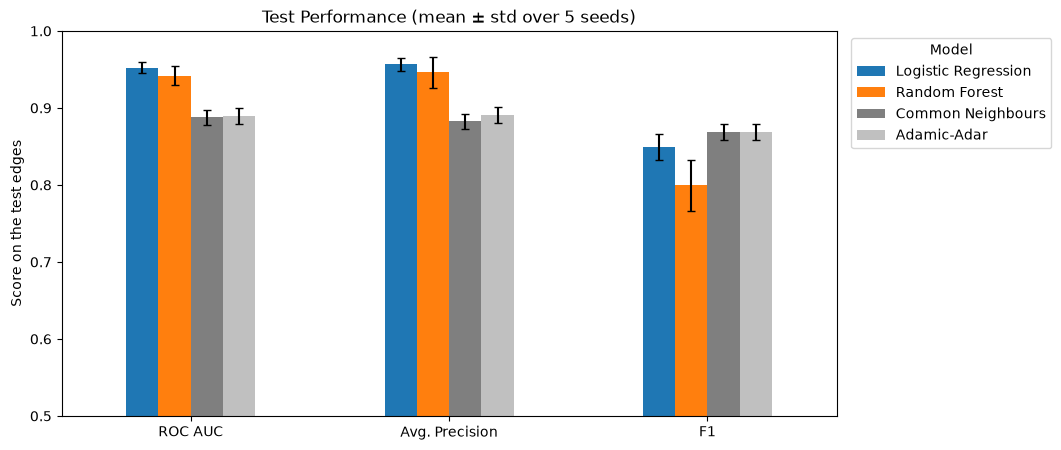

In [34]:
valid_models = model_order[:4]
ax = mean.loc[valid_models, ['ROC AUC', 'Avg. Precision', 'F1']].T.plot.bar(
    yerr=std.loc[valid_models, ['ROC AUC', 'Avg. Precision', 'F1']].T,
    capsize=3, figsize=(10, 5), rot=0,
    color=['tab:blue', 'tab:orange', 'tab:gray', 'silver'])
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score on the test edges')
ax.set_title('Test Performance (mean ± std over 5 seeds)')
ax.legend(title='Model', loc='upper left', bbox_to_anchor=(1.01, 1))
plt.show()

- **Logistic Regression ranks best** (ROC AUC 0.952 ± 0.008), slightly ahead of Random Forest (0.942 ± 0.013) and clearly ahead of the heuristics (≈ 0.89).
- **At the threshold of 0.5, the heuristics reach a higher F1** (0.869 vs. 0.849). The classifiers are trained on edges their embeddings have seen and become very confident on them, while hidden test edges get lower probabilities (recall 0.76). The ranking, which matters for recommendations, is still better.
- **Leakage check:** with embeddings learned on the full graph, the same Random Forest reaches 0.993, so a setup without a proper edge split would be clearly too optimistic.

### 6.7 Final Model

We select **Logistic Regression**: it has the best ranking quality, the lowest variance and is simple and fast. In practice, it should recommend the top-N candidates per product (or use a threshold tuned on the validation set) instead of the fixed threshold 0.5.

<div class="alert alert-block alert-info">

**Key result:** Node2Vec with Logistic Regression recovers hidden co-purchases with a ROC AUC of 0.952 ± 0.008, clearly better than classical heuristics (0.89). Without a proper edge split, the result would be inflated to 0.99.

</div>

## *Task 7 ~  Conclusions and Future Work*

#### **1. Summarize and interpret the achieved results:**
The co-purchasing network is strongly clustered (28× more than random graphs), and Node2Vec with Logistic Regression recovers hidden co-purchases with a ROC AUC of 0.95, clearly better than classical heuristics (0.89).

#### **2. Compare your results to the expected or desired outcomes in the original plan (Task 1):**
The goal was reached: new co-purchases can be predicted reliably. Avoiding information leakage was essential: a naive setup would report a ROC AUC of 0.99, the realistic result is lower but still strong.

#### **3. Explain the generated value! How do the analysis and the selected prediction algorithms help the organization?**
The model ranks product pairs that are not yet linked; the highest-ranked pairs are candidates for new "Frequently bought together" recommendations. The centrality analysis identifies anchor products such as product 8.

#### **4. Recommend a course of action for the organization in your story based on the results:**
Test the top-N suggestions of the model in an A/B test on this product group before applying it to the whole catalogue.

#### **5. Reflect on limitations and possible pitfalls of using these results:**
The sample is small, not random (IDs 0–199) and from 2003. Random negative pairs are easier to separate than real, similar products that are not bought together.

#### **6. Critically discuss the employed methodology:**
Training the classifier on edges that the embeddings have seen makes it overconfident on unseen edges; training it on separately held-out edges would fix this. The Erdős–Rényi comparison ignores the degree cap of 5; a degree-preserving configuration model would be a fairer reference.

#### **7. Propose ideas for future work:**
- SNAP also offers later snapshots of the same network (May and June 2003): train on March and check which predicted edges really appear later.
- Use "hard" negatives, e.g. unconnected products two steps apart, to test the model on realistic candidates.

## *Task 8 ~ Scalability of the Centrality Measures*

Task 5 analysed 380 products, but Amazon's catalogue in this network has 262,111. Before recommending the centrality analysis for the whole catalogue, we measure how the runtime of the NetworkX implementations of **degree**, **betweenness** and **closeness** centrality grows with the size of the network, and estimate the runtime for the full network.

**Setup:**

- **10 subgraph sizes** from 100 to 2,000 products, roughly evenly spaced on a logarithmic scale.
- **10 different subgraphs per size**, each measured with all three measures (the same subgraphs for every measure).
- **Two sampling procedures** for the induced subgraphs:
  - *Random products:* the products are chosen completely at random from the full network.
  - *Connected products:* starting from a random product, products are collected by a breadth-first search (ignoring the edge direction) until the size is reached.
- **Repeated timing for degree centrality:** it takes less than a millisecond, so it is run 100 times on each subgraph and the average is used. Betweenness and closeness take long enough to be timed once.
- The network is unweighted, so no weights have to be removed.

In [35]:
ALL_PRODUCTS = sorted(G.nodes(), key=int)
UNDIRECTED_VIEW = G.to_undirected(as_view=True)


def random_subgraph(graph, size, random_generator):
    """Induced subgraph of `size` products chosen completely at random."""
    return graph.subgraph(random_generator.sample(ALL_PRODUCTS, size)).copy()


def connected_subgraph(graph, size, random_generator):
    """Induced subgraph of `size` connected products (breadth-first search from a random start)."""
    start = random_generator.choice(ALL_PRODUCTS)
    selected, queue = {start}, deque([start])
    while queue and len(selected) < size:
        product_id = queue.popleft()
        neighbours = sorted(UNDIRECTED_VIEW.neighbors(product_id), key=int)
        random_generator.shuffle(neighbours)
        for neighbour in neighbours:
            if len(selected) == size:
                break
            if neighbour not in selected:
                selected.add(neighbour)
                queue.append(neighbour)
    return graph.subgraph(selected).copy()


SAMPLING_PROCEDURES = {'Random products': random_subgraph,
                       'Connected products': connected_subgraph}

The runtimes are measured with `time.perf_counter`. Running this cell takes a few minutes; the exact runtimes depend on the computer, so they can differ slightly between runs.

In [36]:
SUBGRAPH_SIZES = [100, 150, 200, 300, 450, 650, 1000, 1300, 1600, 2000]
SUBGRAPHS_PER_SIZE = 10
DEGREE_REPETITIONS = 100  # degree centrality is too fast to be timed reliably in a single run
CENTRALITY_MEASURES = {'Degree': nx.degree_centrality,
                       'Closeness': nx.closeness_centrality,
                       'Betweenness': nx.betweenness_centrality}


def measure_runtime(function, graph, repetitions=1):
    """Average runtime in seconds of `function(graph)` over `repetitions` runs."""
    start = time.perf_counter()
    for _ in range(repetitions):
        function(graph)
    return (time.perf_counter() - start) / repetitions


random_generator = random.Random(42)
rows = []
for sampling, make_subgraph in SAMPLING_PROCEDURES.items():
    for size in SUBGRAPH_SIZES:
        for _ in range(SUBGRAPHS_PER_SIZE):
            subgraph = make_subgraph(G, size, random_generator)
            for name, function in CENTRALITY_MEASURES.items():
                repetitions = DEGREE_REPETITIONS if name == 'Degree' else 1
                rows.append({'sampling': sampling, 'size': size, 'measure': name,
                             'edges': subgraph.number_of_edges(),
                             'runtime (s)': measure_runtime(function, subgraph, repetitions)})
runtimes = pd.DataFrame(rows)

# Average number of edges of the subgraphs: the sampling procedure changes the graphs completely
(runtimes[runtimes['measure'] == 'Degree']
 .groupby(['sampling', 'size'])['edges'].mean().round().astype(int).unstack())

size,100,150,200,300,450,650,1000,1300,1600,2000
sampling,,,,,,,,,,
Connected products,316,421,553,870,1431,1988,3172,4010,4689,6295
Random products,0,0,0,1,2,7,18,31,44,71


The plots show the mean runtime ± standard deviation over the 10 subgraphs of each size, on the left for random products and on the right for connected products. Both axes are logarithmic: a straight line means that the runtime grows like a power of the size, $t \sim n^b$, and the slope of the line is the exponent $b$.

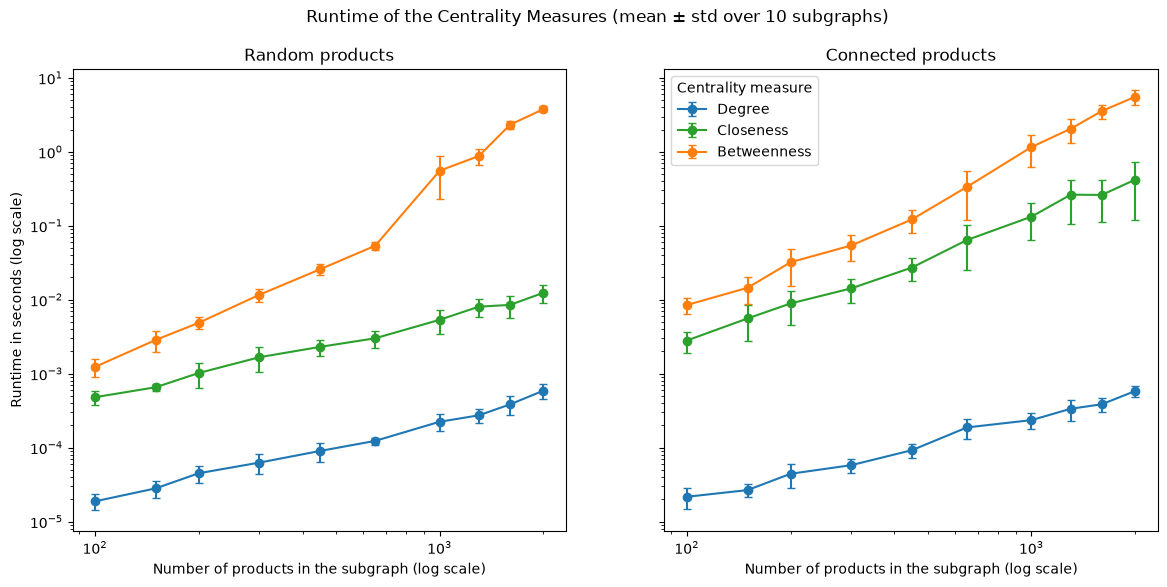

In [37]:
summary = (runtimes.groupby(['sampling', 'measure', 'size'])['runtime (s)']
           .agg(['mean', 'std']).reset_index())
colors = {'Degree': 'tab:blue', 'Closeness': 'tab:green', 'Betweenness': 'tab:orange'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, sampling in zip(axes, SAMPLING_PROCEDURES):
    for name in CENTRALITY_MEASURES:
        group = summary[(summary['sampling'] == sampling) & (summary['measure'] == name)]
        ax.errorbar(group['size'], group['mean'], yerr=group['std'], marker='o', capsize=3,
                    color=colors[name], label=name)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Number of products in the subgraph (log scale)')
    ax.set_title(sampling)
axes[0].set_ylabel('Runtime in seconds (log scale)')
axes[1].legend(title='Centrality measure')
fig.suptitle('Runtime of the Centrality Measures (mean ± std over 10 subgraphs)')
plt.show()

We fit a straight line to the logarithmic means to estimate the growth exponent $b$ of each measure. For the connected subgraphs, which have the same structure as the real network, we use it to extrapolate the runtime to the full network with 262,111 products.

In [38]:
def readable_duration(seconds):
    for unit, length in [('days', 86400), ('hours', 3600), ('minutes', 60)]:
        if seconds >= length:
            return f"{seconds / length:.1f} {unit}"
    if seconds >= 1:
        return f"{seconds:.1f} seconds"
    return f"{seconds * 1000:.1f} ms"


FULL_SIZE = G.number_of_nodes()
growth_rows = []
for sampling in SAMPLING_PROCEDURES:
    for name in CENTRALITY_MEASURES:
        group = summary[(summary['sampling'] == sampling) & (summary['measure'] == name)]
        exponent, intercept = np.polyfit(np.log10(group['size']), np.log10(group['mean']), 1)
        estimate = readable_duration(10 ** (intercept + exponent * np.log10(FULL_SIZE)))
        growth_rows.append({'Sampling': sampling, 'Centrality measure': name,
                            'Growth exponent b (runtime ~ n^b)': round(exponent, 2),
                            'Runtime at 2,000 products': readable_duration(group['mean'].iloc[-1]),
                            'Estimated runtime for 262,111 products':
                                estimate if sampling == 'Connected products' else '–'})
pd.DataFrame(growth_rows).set_index(['Sampling', 'Centrality measure'])

Growth exponent b (runtime ~ n^b)  \
Sampling           Centrality measure                                      
Random products    Degree                                           1.09   
                   Closeness                                        1.08   
                   Betweenness                                      2.75   
Connected products Degree                                           1.11   
                   Closeness                                        1.70   
                   Betweenness                                      2.24   

                                      Runtime at 2,000 products  \
Sampling           Centrality measure                             
Random products    Degree                                0.6 ms   
                   Closeness                            12.4 ms   
                   Betweenness                      3.8 seconds   
Connected products Degree                                0.6 ms   
                   Closeness                           420.1 ms   
                   Betweenness                      5.5 seconds   

                                      Estimated runtime for 262,111 products  
Sampling           Centrality measure                                         
Random products    Degree                                                  –  
                   Closeness                                               –  
                   Betweenness                                             –  
Connected products Degree                                           121.8 ms  
                   Closeness                                    27.7 minutes  
                   Betweenness                                      3.2 days

**Interpretation:**

- **The sampling procedure matters:** products chosen at random form almost empty subgraphs (71 edges for 2,000 products, compared with 6,295 for connected products). Closeness is about 30 times faster on them, so random sampling strongly underestimates the runtime on the real network.
- **Growth on connected subgraphs:** degree grows linearly (b ≈ 1.1), closeness superlinearly (b ≈ 1.7) and betweenness roughly quadratically (b ≈ 2.2). This matches the theory: degree only counts edges, while closeness and betweenness search shortest paths from every product.
- **Full catalogue:** degree would take about 0.1 seconds, closeness about 30 minutes and betweenness about 3 days. For all 262,111 products, betweenness is only feasible with an approximation (e.g. `nx.betweenness_centrality(G, k=...)`, which uses only k start products).

**Critical reflection:**

- The extrapolation goes about 130 times beyond the largest measured size. The subgraphs also have fewer connections per product than the full network (6.3 vs. 9.4 on average), so the estimates are rather a lower bound.
- Connected subgraphs are local neighbourhoods around a start product and do not contain the long paths of the full network.
- Runtimes depend on the computer and its load (visible as outliers in the left plot); 10 subgraphs per size and the standard deviation reduce, but do not remove, this effect.

<div class="alert alert-block alert-info">

**Key result:** degree centrality scales linearly and would take 0.1 seconds for the full catalogue. Closeness (~30 minutes) and especially betweenness (~3 days, growth ≈ n^2.2) need approximations at that scale.

</div>